In [57]:
import sys
import subprocess

def check_environment():
    if 'google.colab' in sys.modules:
        print("Entorno: Google Colab ☁️")
        from google.colab import drive
        drive.mount('/content/drive')

        from IPython import get_ipython
        ipython = get_ipython()

        repo_path = "/content/hands-on-SupCon"

        # Clonar solo si no existe
        if not os.path.exists(repo_path):
            print("Clonando repositorio...")
            subprocess.run(
                ["git", "clone", "https://github.com/unlikeghost/hands-on-SupCon.git"],
                check=True
            )

        # Instalar dependencias
        if ipython:
            ipython.run_line_magic(
                'pip',
                'install --upgrade umap-learn numba'
            )

        # Agregar repo al path para importar src
        if repo_path not in sys.path:
            sys.path.append(repo_path)

        return "colab"

    else:
        print("Entorno: Local / Jupyter Notebook")
        return "local"

env = check_environment()

Entorno: Local / Jupyter Notebook


In [58]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [59]:
import os
import logging

os.environ["TORCH_LOGS"] = "-all"
logging.getLogger("torch._inductor").setLevel(logging.ERROR)

In [60]:
import os
import sys

project_root = (
    "/content/hands-on-SupCon"
    if env == "colab"
    else os.path.abspath(os.path.join(os.getcwd(), ".."))
)

if project_root not in sys.path:
    sys.path.append(project_root)

data_path = os.path.join(project_root, "data")
models_path = os.path.join(project_root, "models")

os.makedirs(data_path, exist_ok=True)
os.makedirs(models_path, exist_ok=True)

num_workers = 2 if env == "colab" else 6

## Librerias

In [61]:
import umap
import torch
import random
import torchvision

import numpy as np
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

from torchsummary import summary
from sklearn.metrics import confusion_matrix

In [62]:
from src.models import MiniConvNetClassifier
from src.plot_data import show_batch, show_features, plot_latent_space_3d, plot_latent_space_2d
from src.datasets import ClassificationDataset

## 🔒 Semilla para reproducibilidad

In [63]:
seed: int = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

## ⚡ Optimización de Aceleración por Hardware (CUDA/cuDNN)

### 🚀 Verificar uso de GPU (si está disponible)

In [64]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
    )
print(f"Status: System ready on {device}")

Status: System ready on cuda


In [65]:
if device == 'cuda':
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.allow_tf32 = True

## 🧪 Implementación

### 📦 Carga y preprocesamiento de datos

In [66]:
batch_size: int = 512

train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(size=(32, 32), scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

val_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

classes: tuple = (
    'plane', 'car', 'bird', 'cat',
    'deer', 'dog', 'frog', 'horse',
    'ship', 'truck'
)

In [67]:
test_data = torchvision.datasets.CIFAR10(
    root=data_path,
    train=False,
    download=True,
)

full_train_dataset = torchvision.datasets.CIFAR10(
    root=data_path,
    train=True,
    download=True,
)

# Definimos los tamaños (80% train, 20% val)
train_size = int(len(full_train_dataset) * .8)
val_size = int(len(full_train_dataset) - train_size)

train_size, val_size, len(test_data)

(40000, 10000, 10000)

In [68]:
train_data, val_data = torch.utils.data.random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

In [69]:
train_dataset = ClassificationDataset(
    dataset=train_data,
    transform=train_transform
)
val_dataset = ClassificationDataset(
    dataset=val_data,
    transform=val_transform
)

test_dataset  = ClassificationDataset(
    dataset=test_data,
    transform=val_transform
)

In [70]:
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    persistent_workers=True,
    pin_memory=True
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True
)

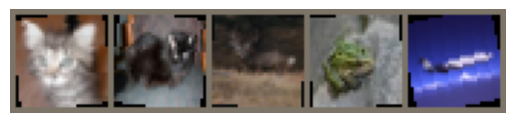

In [71]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images[:5]

show_batch(
    torchvision.utils.make_grid(images),
)

### 🧠 CNN

In [72]:
model = MiniConvNetClassifier().to(device)
print(model)
summary(model, input_size=(3, 32, 32))

MiniConvNetClassifier(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (mlp): Sequential(
    (0): Linear(in_features=4096, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=254, bias=True)
    (3): ReLU()
    (4): Linear(in_features=254, out_features=10, bias=True)
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 3

### ⚙️ Proceso de entrenamiento

#### 🚀 Entrenamiento del modelo


In [73]:
num_epochs: int = 200

criterion = nn.CrossEntropyLoss() # función de perdida
optimizer = optim.Adam(model.parameters(), lr=1e-3) # Optimizador

In [74]:
train_loss, val_loss = [], []
train_acc, val_acc = [], []

for epoch in range(num_epochs):

    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        # Métricas de entrenamiento
        running_train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    # --- FASE DE VALIDACIÓN ---
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            # Métricas de validación
            running_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Cálculo de promedios por época
    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_acc = train_correct / train_total

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = val_correct / val_total

    # Guardar historial
    train_loss.append(epoch_train_loss)
    train_acc.append(epoch_train_acc)
    val_loss.append(epoch_val_loss)
    val_acc.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}")

Epoch [1/200] Train Loss: 1.6177, Acc: 0.4077 | Val Loss: 1.3336, Acc: 0.5156
Epoch [2/200] Train Loss: 1.2530, Acc: 0.5492 | Val Loss: 1.0793, Acc: 0.6148
Epoch [3/200] Train Loss: 1.1114, Acc: 0.6036 | Val Loss: 1.0079, Acc: 0.6372
Epoch [4/200] Train Loss: 1.0219, Acc: 0.6349 | Val Loss: 0.9779, Acc: 0.6532
Epoch [5/200] Train Loss: 0.9671, Acc: 0.6561 | Val Loss: 0.9844, Acc: 0.6656
Epoch [6/200] Train Loss: 0.9017, Acc: 0.6825 | Val Loss: 0.8871, Acc: 0.6847
Epoch [7/200] Train Loss: 0.8549, Acc: 0.6988 | Val Loss: 0.8828, Acc: 0.6958
Epoch [8/200] Train Loss: 0.8339, Acc: 0.7061 | Val Loss: 0.8474, Acc: 0.6986
Epoch [9/200] Train Loss: 0.7961, Acc: 0.7205 | Val Loss: 0.7953, Acc: 0.7151
Epoch [10/200] Train Loss: 0.7655, Acc: 0.7310 | Val Loss: 0.7765, Acc: 0.7323
Epoch [11/200] Train Loss: 0.7436, Acc: 0.7380 | Val Loss: 0.7925, Acc: 0.7235
Epoch [12/200] Train Loss: 0.7152, Acc: 0.7474 | Val Loss: 0.8317, Acc: 0.7113
Epoch [13/200] Train Loss: 0.6866, Acc: 0.7595 | Val Loss: 0.

### 📊 Métricas de entrenamiento y validación

#### 📊 Entrenamiento

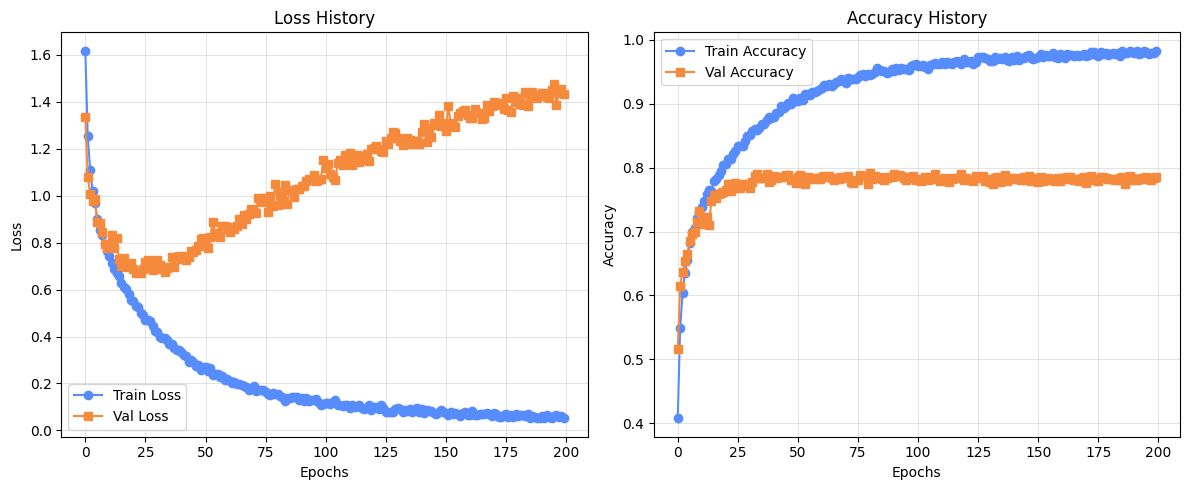

In [75]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(train_loss, label='Train Loss', marker='o')
axs[0].plot(val_loss, label='Val Loss', marker='s') # Agregado
axs[0].set_title('Loss History')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(train_acc, label='Train Accuracy', marker='o')
axs[1].plot(val_acc, label='Val Accuracy', marker='s') # Agregado
axs[1].set_title('Accuracy History')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

#### 📊 Validación

In [76]:
model.eval() # Nos aseguramos de que esté en modo evaluación

all_preds = []
all_labels = []

# 1. Pasamos TODAS las imágenes de test por el modelo sin calcular gradientes
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)

        # torch.max nos devuelve el valor máximo y su ÍNDICE (la clase predicha)
        _, predicted = torch.max(outputs, 1)

        # Guardamos las predicciones y las etiquetas reales en la CPU
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

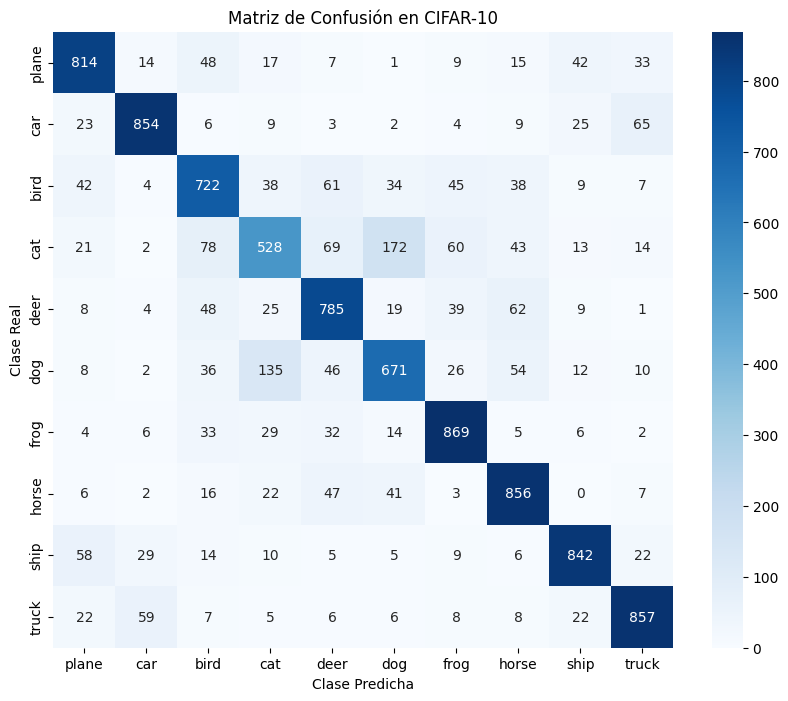

In [77]:
# 2. Creamos la matriz numérica con sklearn
cm = confusion_matrix(all_labels, all_preds)

# 3. Dibujamos la matriz
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.title('Matriz de Confusión en CIFAR-10')
plt.show()

### 🔍 Visualización de features

#### 🧩 Feature Maps

In [78]:
model.eval()

images_batch, labels_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

images_batch = images_batch[:5, :, :, :]

with torch.no_grad():
    # Extraer features de la PRIMERA capa (índice 0 es Conv1, índice 1 es ReLU)
    # Pasamos solo por las primeras 2 capas del bloque
    features_conv1 = model.feature_extractor[:2](images_batch)

    # Extraer features de la SEGUNDA capa (índice 3 es Conv2, índice 4 es ReLU)
    # Pasamos por las primeras 5 capas del bloque
    features_conv2 = model.feature_extractor[:5](images_batch)


images_np = images_batch.cpu().numpy()
feat1_np = features_conv1.cpu().numpy() # Forma: (32, 6, 28, 28)
feat2_np = features_conv2.cpu().numpy() # Forma: (32, 16, 10, 10)

feat1_np.shape, feat2_np.shape

((5, 32, 32, 32), (5, 64, 16, 16))

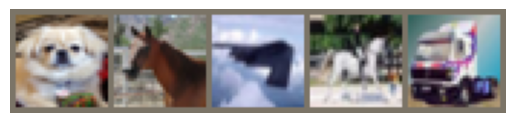

Canal 0


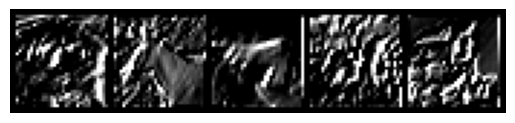

Canal 1


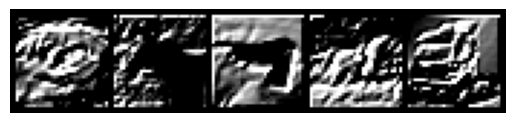

Canal 2


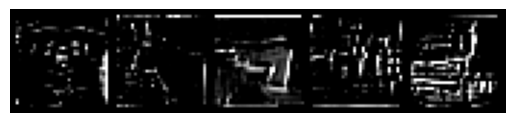

Canal 3


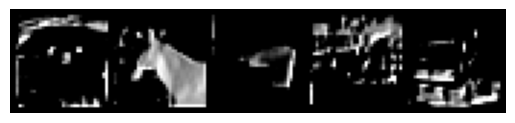

Canal 4


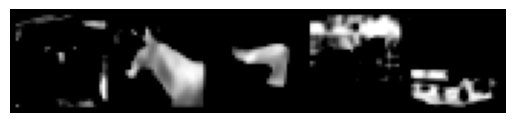

Canal 5


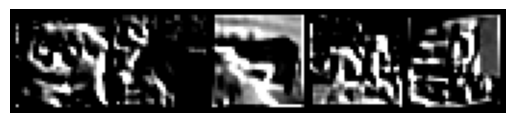

Canal 0


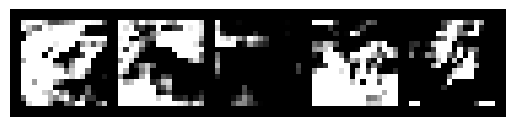

Canal 1


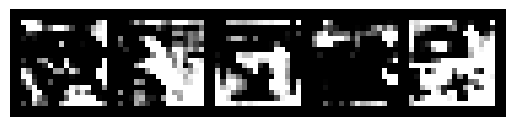

Canal 2


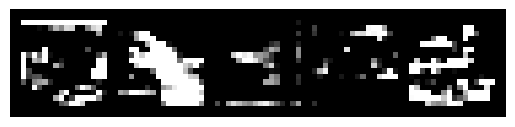

Canal 3


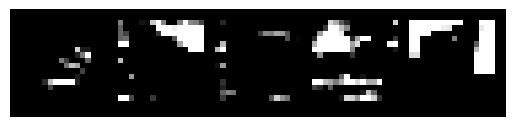

Canal 4


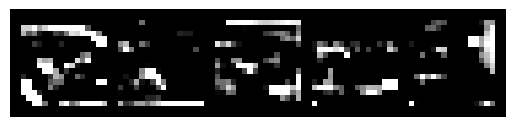

Canal 5


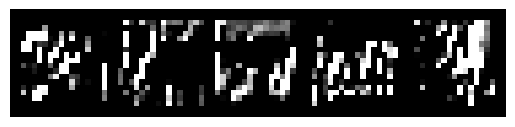

Canal 6


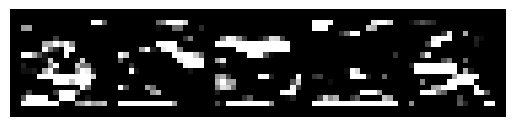

Canal 7


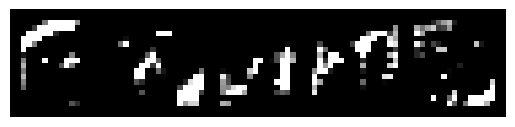

Canal 8


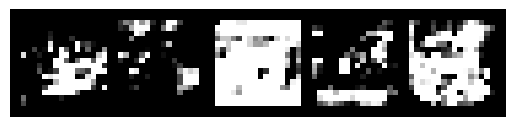

Canal 9


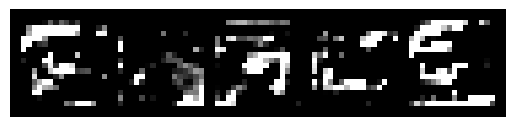

Canal 10


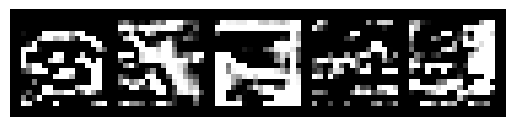

Canal 11


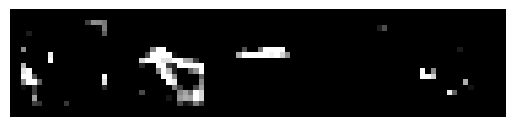

Canal 12


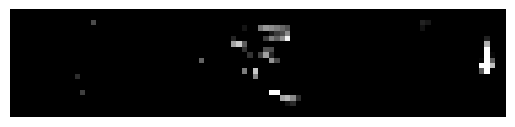

Canal 13


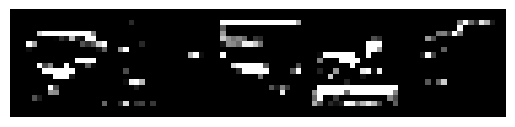

Canal 14


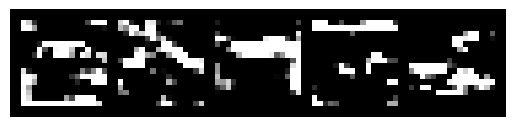

Canal 15


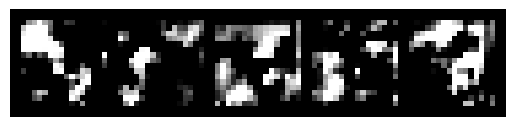

In [79]:
show_batch(
    torchvision.utils.make_grid(images_batch.to('cpu')),
)

for i in range(0, 6):
  print(f"Canal {i}")
  show_features(features_conv1, filter_index=i)

for i in range(0, 16):
  print(f"Canal {i}")
  show_features(features_conv2, filter_index=i)

#### 🧩 Proyección del espacio latente

In [80]:
model.eval()

all_features = []
all_labels = []

# 1. Extraemos representaciones latentes (antes de la capa final)
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # CNN
        x = model.feature_extractor(images)
        x = x.view(x.size(0), -1)

        # Pasamos por el MLP SIN la última capa (clasificación)
        x = model.mlp[:-1](x)

        # Guardamos
        all_features.append(x.cpu().numpy())
        all_labels.append(labels.numpy())

# Concatenamos todo en un solo array gigante
all_features = np.concatenate(all_features, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

all_features.shape, all_labels.shape

((10000, 254), (10000,))

##### 🧩 3D

In [81]:
umap_embeddings = umap.UMAP(n_components=3).fit_transform(all_features)
umap_embeddings.shape

(10000, 3)

In [82]:
plot_latent_space_3d(
    umap_embeddings,
    all_labels,
    classes
)

##### 🧩 2D

In [83]:
umap_embeddings_2d = umap.UMAP(n_components=2).fit_transform(all_features)
umap_embeddings_2d.shape

(10000, 2)

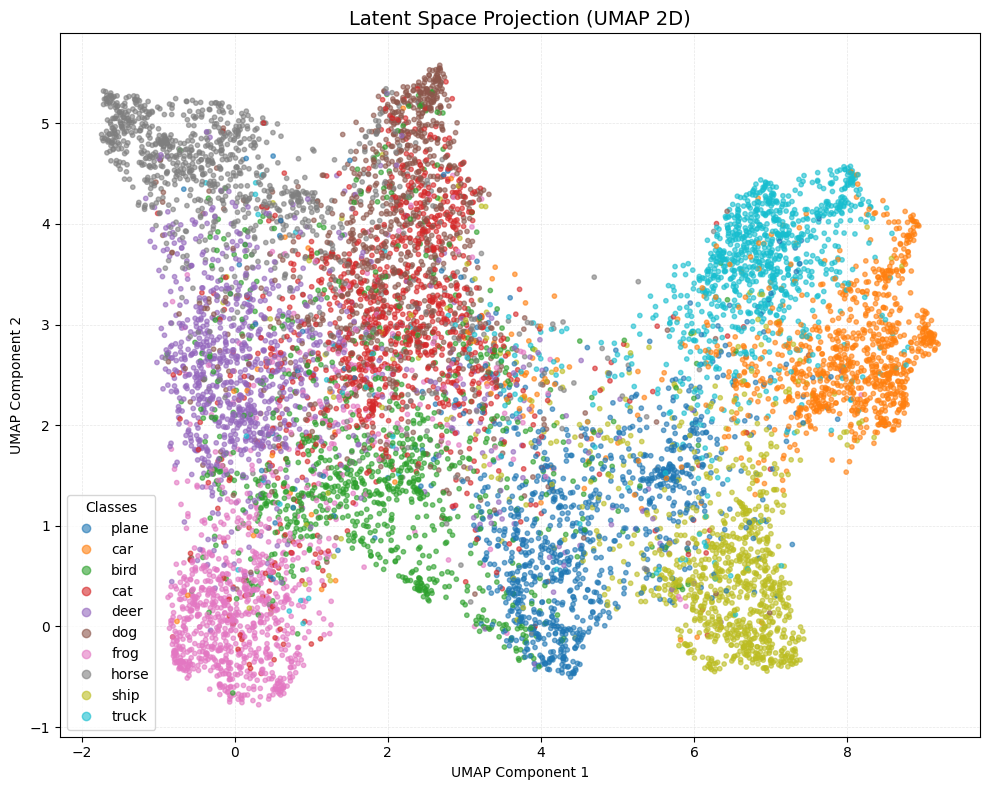

In [84]:
plot_latent_space_2d(
    umap_embeddings_2d,
    all_labels,
    classes
)